In [30]:
import numpy as np
import matplotlib.pyplot as plt

__1. Генерация синтетических данных__

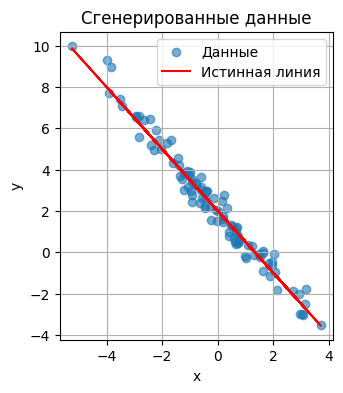

In [31]:
np.random.seed(42)
n_samples = 100
X = np.random.randn(n_samples) * 2
true_w = -1.5
true_b = 2
eps = np.random.randn(n_samples) * 0.5
y = true_w * X + true_b + eps


plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(X, y, alpha=0.6, label='Данные')
plt.plot(X, true_w * X + true_b, 'r-', label='Истинная линия')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сгенерированные данные')
plt.legend()
plt.grid(True)

__2. Реализация SGD с затухающей скоростью обучения__

In [32]:
w, b = 5.0, 5.0
lr0 = 0.1
decay_rate = 0.01
n_epochs = 100
batch_size = 10
n_batches = n_samples // batch_size

w_history = [w]
b_history = [b]
loss_history = []
lr_history = []

for epoch in range(n_epochs):
    lr = lr0 / (1 + decay_rate * epoch)
    lr_history.append(lr)
    
    indices = np.random.permutation(n_samples)
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    
    epoch_loss = 0
    
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        y_pred = w * X_batch + b
        
        dw = -2 * np.mean(X_batch * (y_batch - y_pred))
        db = -2 * np.mean(y_batch - y_pred)
        
        w -= lr * dw
        b -= lr * db
        
        batch_loss = np.mean((y_batch - y_pred) ** 2)
        epoch_loss += batch_loss * len(X_batch)
    
    epoch_loss /= n_samples
    loss_history.append(epoch_loss)
    w_history.append(w)
    b_history.append(b)

    if (epoch + 1) % 10 == 0:
        print(f"Эпоха {epoch+1:3d}, lr={lr:.6f}, w={w:.4f}, b={b:.4f}, loss={epoch_loss:.6f}")

Эпоха  10, lr=0.091743, w=-1.5597, b=1.9965, loss=0.238627
Эпоха  20, lr=0.084034, w=-1.5674, b=2.0156, loss=0.231419
Эпоха  30, lr=0.077519, w=-1.5384, b=2.0068, loss=0.246060
Эпоха  40, lr=0.071942, w=-1.5024, b=2.0249, loss=0.228137
Эпоха  50, lr=0.067114, w=-1.6072, b=1.9900, loss=0.229789
Эпоха  60, lr=0.062893, w=-1.5931, b=2.0157, loss=0.229065
Эпоха  70, lr=0.059172, w=-1.5431, b=2.0202, loss=0.234277
Эпоха  80, lr=0.055866, w=-1.4897, b=1.9838, loss=0.225230
Эпоха  90, lr=0.052910, w=-1.5196, b=1.9955, loss=0.231522
Эпоха 100, lr=0.050251, w=-1.5146, b=1.9798, loss=0.225343


__3. Финальные параметры__

In [33]:
print(f"\nФинальные параметры: w = {w:.4f}, b = {b:.4f}")
print(f"Финальный loss: {loss_history[-1]:.6f}")
print(f"Истинные параметры: w = {true_w:.1f}, b = {true_b:.1f}")


Финальные параметры: w = -1.5146, b = 1.9798
Финальный loss: 0.225343
Истинные параметры: w = -1.5, b = 2.0


__4. Построение графиков сходимости__

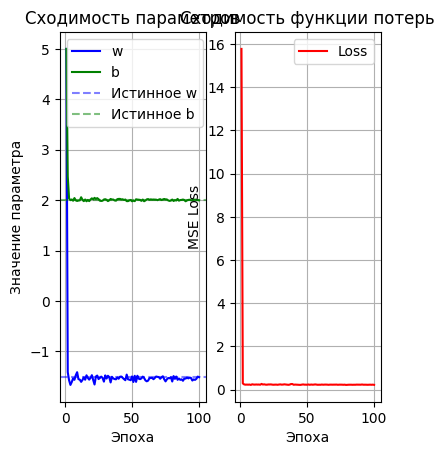

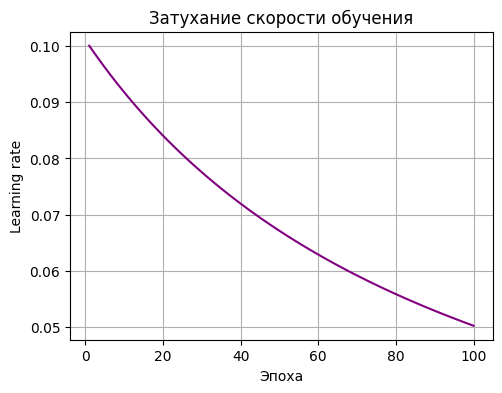

In [34]:
plt.subplot(1, 3, 2)
epochs = range(1, n_epochs + 1)
plt.plot(epochs, w_history[:-1], 'b-', label='w')
plt.plot(epochs, b_history[:-1], 'g-', label='b')
plt.axhline(y=true_w, color='b', linestyle='--', alpha=0.5, label='Истинное w')
plt.axhline(y=true_b, color='g', linestyle='--', alpha=0.5, label='Истинное b')
plt.xlabel('Эпоха')
plt.ylabel('Значение параметра')
plt.title('Сходимость параметров')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs, loss_history, 'r-', label='Loss')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.title('Сходимость функции потерь')
plt.legend()
plt.grid(True)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, lr_history, 'purple')
plt.xlabel('Эпоха')
plt.ylabel('Learning rate')
plt.title('Затухание скорости обучения')
plt.grid(True)

__Линия регрессии__

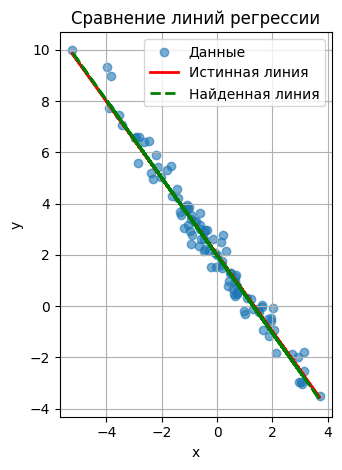

In [35]:
plt.subplot(1, 2, 2)

plt.scatter(X, y, alpha=0.6, label='Данные')
plt.plot(X, true_w * X + true_b, 'r-', label='Истинная линия', linewidth=2)
plt.plot(X, w * X + b, 'g--', label='Найденная линия', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение линий регрессии')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()